In [23]:
import torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from torchvision.models.resnet import Bottleneck
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import csv
from tqdm import tqdm

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [9]:

# Transform (convert to tensor + normalize)
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])


# Download and load training set
train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Download and load test set
test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


In [10]:
# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [11]:
model = models.resnet152(weights=models.ResNet152_Weights.DEFAULT)


In [12]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [13]:
num_classes = len(train_dataset.classes)
in_features = model.fc.in_features

model.fc = nn.Linear(in_features, num_classes)


In [14]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

fc.weight
fc.bias


In [15]:
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [16]:
weights = models.ResNet152_Weights.DEFAULT
model = model.to(device)

epochs = 3

for epoch in range(epochs):

    #  TRAIN 
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100 * correct / total


    #  VALIDATION 
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = outputs.max(1)

            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_acc = 100 * val_correct / val_total

    print(f"Epoch {epoch+1}: Train Acc={train_acc:.2f}% | Val Acc={val_acc:.2f}%")


Epoch 1: Train Acc=78.44% | Val Acc=82.58%
Epoch 2: Train Acc=83.54% | Val Acc=84.63%
Epoch 3: Train Acc=84.80% | Val Acc=84.56%


In [17]:
from torchvision.models.resnet import Bottleneck

def disable_skip_connections(model, target_layer="layer3", num_blocks=2):
    count = 0

    for name, module in model.named_modules():
        if target_layer in name and isinstance(module, Bottleneck):

            if count >= num_blocks:
                break

            def forward_no_skip(self, x):
                out = self.conv1(x)
                out = self.bn1(out)
                out = self.relu(out)

                out = self.conv2(out)
                out = self.bn2(out)
                out = self.relu(out)

                out = self.conv3(out)
                out = self.bn3(out)

                out = self.relu(out)
                return out

            module.forward = forward_no_skip.__get__(module, Bottleneck)

            print("Disabled skip connection in:", name)
            count += 1


# LOAD MODEL
model = models.resnet152(weights=models.ResNet152_Weights.DEFAULT)

# DISABLE SKIP CONNECTIONS (first 2 blocks of layer3)
disable_skip_connections(model, target_layer="layer3", num_blocks=2)
# REPLACE CLASSIFIER HEAD


model.fc = nn.Linear(model.fc.in_features, 10)


# FREEZE BACKBONE


for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True



# TRAINING SETUP


model = model.to(device)

optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

epochs = 3



# TRAIN + VALIDATE


for epoch in range(epochs):

    #  TRAIN 
    model.train()
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100 * correct / total


    #  VALIDATION 
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = outputs.max(1)

            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_acc = 100 * val_correct / val_total

    print(f"Epoch {epoch+1}: Train Acc={train_acc:.2f}% | Val Acc={val_acc:.2f}%")



Disabled skip connection in: layer3.0
Disabled skip connection in: layer3.1
Epoch 1: Train Acc=16.22% | Val Acc=18.17%
Epoch 2: Train Acc=18.66% | Val Acc=18.14%
Epoch 3: Train Acc=18.98% | Val Acc=19.41%


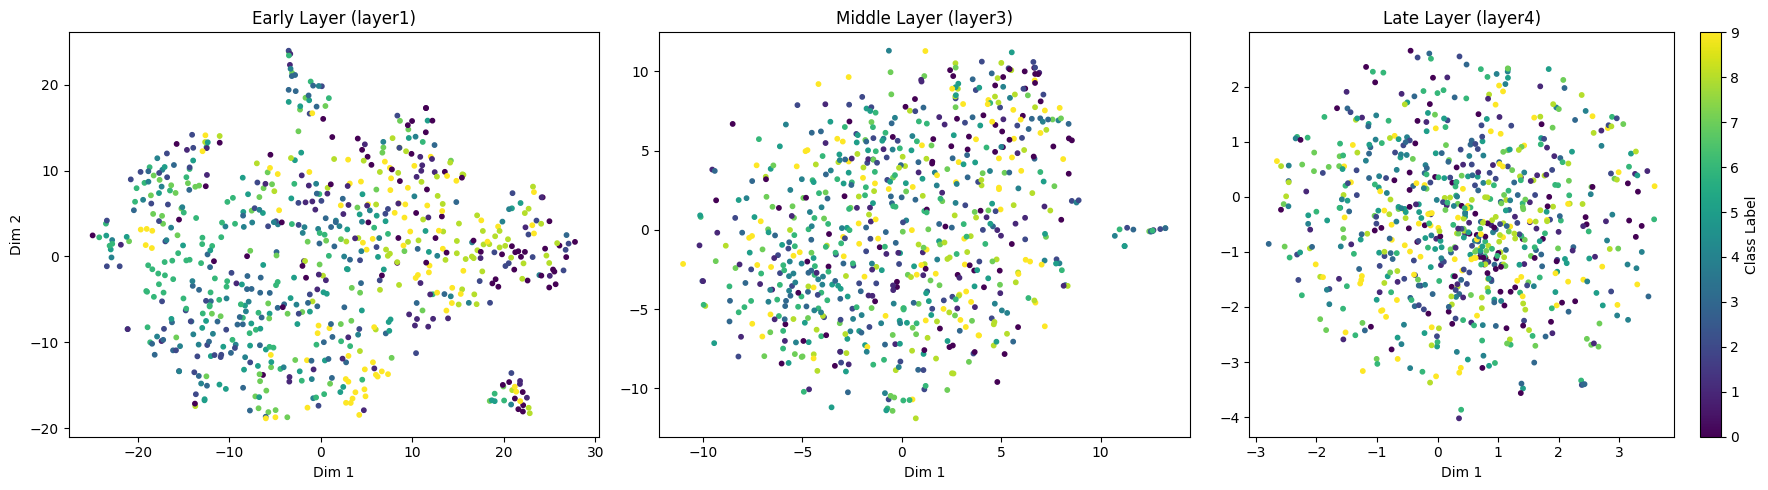

In [19]:
# -------------------------
# Feature Extraction Hooks
# -------------------------

features = {}

def get_hook(name):
    def hook(model, input, output):
        features[name] = output.detach()
    return hook

model.layer1.register_forward_hook(get_hook("early"))
model.layer3.register_forward_hook(get_hook("middle"))
model.layer4.register_forward_hook(get_hook("late"))


# -------------------------
# Collect Features
# -------------------------

all_early = []
all_middle = []
all_late = []
all_labels = []

model.eval()

with torch.no_grad():
    for i, (images, labels) in enumerate(test_loader):
        images = images.to(device)

        _ = model(images)

        early_feat = features["early"].mean(dim=[2, 3]).cpu()
        middle_feat = features["middle"].mean(dim=[2, 3]).cpu()
        late_feat = features["late"].mean(dim=[2, 3]).cpu()

        all_early.append(early_feat)
        all_middle.append(middle_feat)
        all_late.append(late_feat)
        all_labels.append(labels)

        if i == 10:   # ~640 samples
            break


early_feat = torch.cat(all_early)
middle_feat = torch.cat(all_middle)
late_feat = torch.cat(all_late)
labels = torch.cat(all_labels)


# -------------------------
# t-SNE Projection
# -------------------------


tsne_early = TSNE(n_components=2, perplexity=40, random_state=42, init="pca")
tsne_middle = TSNE(n_components=2, perplexity=40, random_state=42, init="pca")
tsne_late = TSNE(n_components=2, perplexity=40, random_state=42, init="pca")

early_embedded = tsne_early.fit_transform(early_feat)
middle_embedded = tsne_middle.fit_transform(middle_feat)
late_embedded = tsne_late.fit_transform(late_feat)


# -------------------------
# Visualization (3 Panels)
# -------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))

# Early Layer
plt.subplot(1, 3, 1)
plt.scatter(early_embedded[:, 0], early_embedded[:, 1], c=labels, s=10)
plt.title("Early Layer (layer1)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

# Middle Layer
plt.subplot(1, 3, 2)
plt.scatter(middle_embedded[:, 0], middle_embedded[:, 1], c=labels, s=10)
plt.title("Middle Layer (layer3)")
plt.xlabel("Dim 1")

# Late Layer
plt.subplot(1, 3, 3)
plt.scatter(late_embedded[:, 0], late_embedded[:, 1], c=labels, s=10)
plt.title("Late Layer (layer4)")
plt.xlabel("Dim 1")

plt.colorbar(label="Class Label", ax=plt.subplot(1,3,3))
plt.tight_layout()
plt.show()


In [ ]:

csv_file = "transfer_learning_results.csv"

with open(csv_file, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Experiment", "Epoch", "Train_Accuracy", "Val_Accuracy"])


# -------------------------
# Experiment Configurations
# -------------------------

configs = [
    {"name": "Pretrained + Partial FT", "weights": models.ResNet152_Weights.DEFAULT, "mode": "partial"},
    {"name": "Pretrained + Full FT", "weights": models.ResNet152_Weights.DEFAULT, "mode": "full"},
    {"name": "Scratch + Full FT", "weights": None, "mode": "full"},
]


# -------------------------
# Training Loop
# -------------------------

for cfg in configs:

    print("\n==============================")
    print("Running:", cfg["name"])
    print("==============================")

    # Load model
    model = models.resnet152(weights=cfg["weights"])

    # Replace classifier head
    num_classes = len(train_dataset.classes)
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    # Freezing strategy
    if cfg["mode"] == "partial":

        # Freeze all
        for param in model.parameters():
            param.requires_grad = False

        # Unfreeze last block + classifier
        for param in model.layer4.parameters():
            param.requires_grad = True

        for param in model.fc.parameters():
            param.requires_grad = True

        optimizer = optim.Adam([
            {"params": model.layer4.parameters(), "lr": 1e-4},
            {"params": model.fc.parameters(), "lr": 1e-3}
        ])

    else:  # Full fine-tuning

        for param in model.parameters():
            param.requires_grad = True

        optimizer = optim.Adam(model.parameters(), lr=1e-4)


    # Move to GPU
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    epochs = 5


    # -------------------------
    # Epoch Loop
    # -------------------------

    for epoch in range(epochs):

        # -------- TRAIN --------
        model.train()

        train_correct = 0
        train_total = 0

        train_bar = tqdm(train_loader, desc=f"{cfg['name']} | Epoch {epoch+1} Train")

        for images, labels in train_bar:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

            train_bar.set_postfix(loss=loss.item())

        train_acc = 100 * train_correct / train_total


        # -------- VALIDATION --------
        model.eval()

        val_correct = 0
        val_total = 0

        val_bar = tqdm(test_loader, desc=f"{cfg['name']} | Epoch {epoch+1} Val")

        with torch.no_grad():
            for images, labels in val_bar:

                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                outputs = model(images)
                _, predicted = outputs.max(1)

                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_acc = 100 * val_correct / val_total


        # -------- Logging --------

        print(f"{cfg['name']} | Epoch {epoch+1}: Train={train_acc:.2f}% Val={val_acc:.2f}%")

        with open(csv_file, "a", newline="") as f:
            writer = csv.writer(f)
            writer.writerow([cfg["name"], epoch+1, train_acc, val_acc])


print("\nAll experiments finished.")
print("Results saved to:", csv_file)


Running: Pretrained + Partial FT


Pretrained + Partial FT | Epoch 1 Train: 100%|██████████| 782/782 [02:15<00:00,  5.79it/s, loss=0.618]
Pretrained + Partial FT | Epoch 1 Val: 100%|██████████| 157/157 [00:23<00:00,  6.56it/s]


Pretrained + Partial FT | Epoch 1: Train=85.18% Val=89.95%


Pretrained + Partial FT | Epoch 2 Train: 100%|██████████| 782/782 [02:15<00:00,  5.77it/s, loss=0.205] 
Pretrained + Partial FT | Epoch 2 Val: 100%|██████████| 157/157 [00:24<00:00,  6.43it/s]


Pretrained + Partial FT | Epoch 2: Train=93.59% Val=90.51%


...

Pretrained + Full FT | Epoch 2 Train: 100%|██████████| 782/782 [2:13:29<00:00, 10.24s/it, loss=0.0511]   
Pretrained + Full FT | Epoch 2 Val: 100%|██████████| 157/157 [00:56<00:00,  2.79it/s]


Pretrained + Full FT | Epoch 2: Train=98.22% Val=96.74%


Pretrained + Full FT | Epoch 3 Train: 100%|██████████| 782/782 [2:13:36<00:00, 10.25s/it, loss=0.136]    
Pretrained + Full FT | Epoch 3 Val: 100%|██████████| 157/157 [00:56<00:00,  2.78it/s]


Pretrained + Full FT | Epoch 3: Train=98.96% Val=96.86%


Pretrained + Full FT | Epoch 4 Train:  50%|████▉     | 388/782 [1:06:25<1:08:33, 10.44s/it, loss=0.00322]